In [3]:
import numpy as np
import glob
import os
results_dir = '/projectnb/modislc/users/danc/SOFM/sofm_sim_study_fixphi/'
file_pattern = os.path.join(results_dir, "compTime*.csv")
files = glob.glob(file_pattern)
print(f"Found {len(files)} result files. Loading...")
data_list = [np.atleast_2d(np.loadtxt(f, delimiter=',')) for f in files]
final_results = np.concatenate(data_list, axis=0)

Found 197 result files. Loading...


In [2]:
final_results

array([[3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        1.00000000e+01, 1.10000000e+01, 3.55318952e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        1.00000000e+01, 1.60000000e+01, 2.82732487e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        2.00000000e+01, 1.70000000e+01, 5.26891112e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        1.00000000e+01, 1.50000000e+01, 3.17601418e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        1.00000000e+01, 7.00000000e+00, 3.85345864e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        1.00000000e+01, 2.00000000e+00, 3.43204069e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        2.00000000e+01, 1.90000000e+01, 5.19515300e+00],
       [3.00000000e+03, 5.00000000e+00, 2.00000000e+01, 2.00000000e+00,
        2.00000000e+01, 1

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

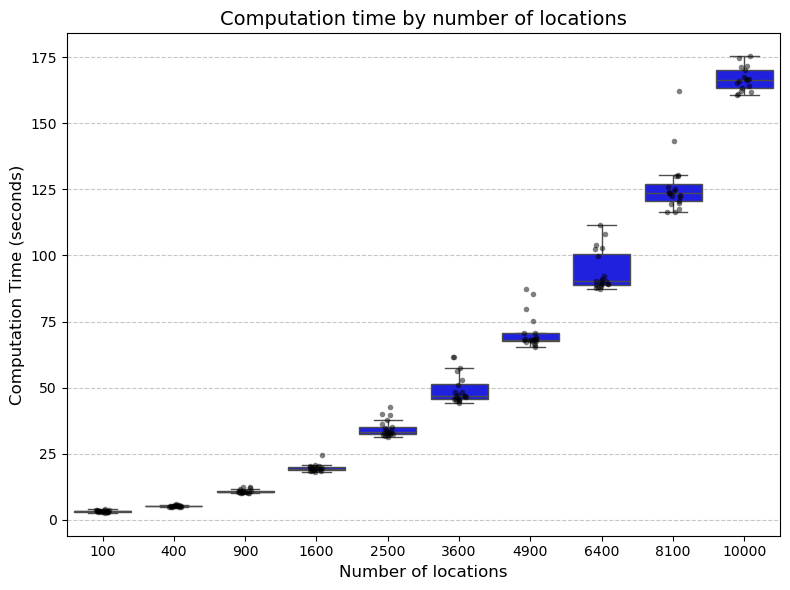

In [15]:
data = final_results
sq_len = data[:, -3].astype(int)
run_time = data[:, -1]

# Load into a DataFrame for Seaborn
df = pd.DataFrame({'Number of locations': sq_len**2, 'run_time': run_time})

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Number of locations', y='run_time', data=df, color='blue',showfliers=False)
sns.stripplot(x='Number of locations', y='run_time', data=df, color='black', alpha=0.5, size=4)

# Formatting
plt.xlabel('Number of locations', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.title('Computation time by number of locations', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save or show
plt.savefig('comp_time_boxplot.png')

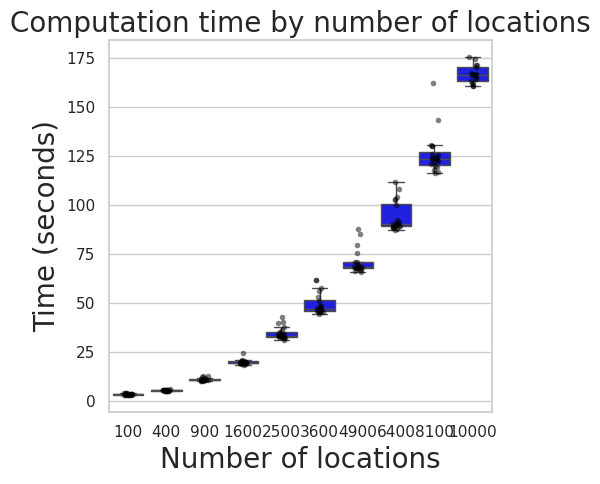

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming final_results is defined in your environment
data = final_results
sq_len = data[:, -3].astype(int)
run_time = data[:, -1]

# Load into a DataFrame for Seaborn
df = pd.DataFrame({'Number of locations': sq_len**2, 'run_time': run_time})

# --- Apply Style Settings ---
titlesize = 20
labelsize = 20
sns.set_theme(style="whitegrid")

# Create the figure and axis using subplots (matching style)
fig, ax = plt.subplots(figsize=(5, 5))

# Create the box plot and strip plot directly on the axis
sns.boxplot(data=df, x='Number of locations', y='run_time', ax=ax, color='blue', showfliers=False)
sns.stripplot(data=df, x='Number of locations', y='run_time', ax=ax, color='black', alpha=0.5, size=4)

# Formatting
ax.set_title('Computation time by number of locations', fontsize=titlesize)
ax.set_ylabel('Time (seconds)', fontsize=labelsize)
ax.set_xlabel('Number of locations', fontsize=labelsize)

plt.tight_layout()
# Save with high DPI and close to prevent memory leaks/flooding
plt.savefig('comp_time_boxplot.png', dpi=300)
plt.show()
plt.close()

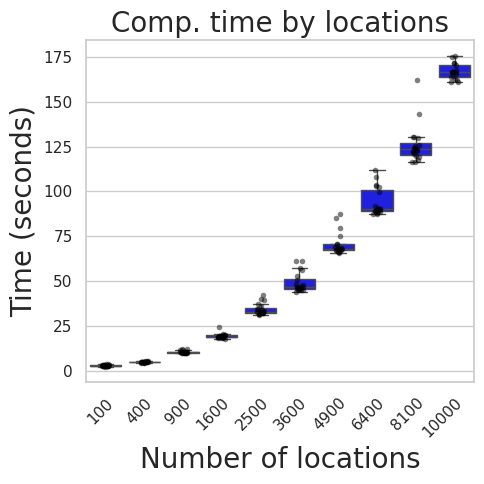

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming final_results is defined in your environment
data = final_results
sq_len = data[:, -3].astype(int)
run_time = data[:, -1]

# Load into a DataFrame for Seaborn
df = pd.DataFrame({'Number of locations': sq_len**2, 'run_time': run_time})

# --- Apply Style Settings ---
titlesize = 20
labelsize = 20
sns.set_theme(style="whitegrid")

# Create the figure and axis using subplots (matching style)
fig, ax = plt.subplots(figsize=(5, 5))

# Create the box plot and strip plot directly on the axis
sns.boxplot(data=df, x='Number of locations', y='run_time', ax=ax, color='blue', showfliers=False)
sns.stripplot(data=df, x='Number of locations', y='run_time', ax=ax, color='black', alpha=0.5, size=4)

# Formatting
ax.set_title('Comp. time by locations', fontsize=titlesize)
ax.set_ylabel('Time (seconds)', fontsize=labelsize)
ax.set_xlabel('Number of locations', fontsize=labelsize)

# --- NEW LINE: Rotate x-axis labels by 45 degrees and align them ---
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

plt.tight_layout()
# Save with high DPI and close to prevent memory leaks/flooding
plt.savefig('comp_time_boxplot.png', dpi=300)
plt.show()
plt.close()

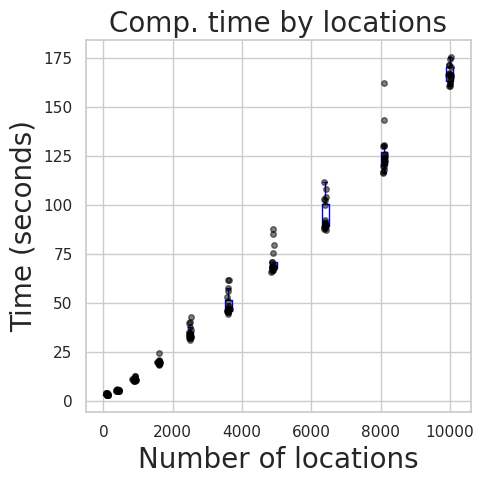

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming final_results is defined in your environment
data = final_results
sq_len = data[:, -3].astype(int)
run_time = data[:, -1]

# Load into a DataFrame
df = pd.DataFrame({'Number of locations': sq_len**2, 'run_time': run_time})

# --- Apply Style Settings ---
titlesize = 20
labelsize = 20
sns.set_theme(style="whitegrid")

# Create the figure (made slightly wider to accommodate the large continuous x-axis range)
fig, ax = plt.subplots(figsize=(5, 5))

# 1. Group the data by our continuous x-variable
groups = df.groupby('Number of locations')
positions = np.array(list(groups.groups.keys()))
plot_data = [group['run_time'].values for name, group in groups]

# 2. Calculate a dynamic box width (roughly 2% of the total x-axis range)
# This prevents boxes from overlapping or looking impossibly thin
x_range = positions.max() - positions.min()
box_width = x_range * 0.02 

# 3. Plot the continuous boxplots using Matplotlib
# manage_ticks=False prevents Matplotlib from treating the axis as categorical
ax.boxplot(plot_data, positions=positions, widths=box_width, 
           boxprops=dict(color='blue'), 
           medianprops=dict(color='blue'), 
           whiskerprops=dict(color='blue'), 
           capprops=dict(color='blue'), 
           showfliers=False, manage_ticks=False)

# 4. Replicate the Seaborn stripplot using a scatter plot with manual x-jitter
for pos, values in zip(positions, plot_data):
    # Add slight random noise to the x-coordinate so points don't stack directly on top of each other
    jitter = np.random.normal(0, box_width * 0.1, size=len(values))
    ax.scatter(np.repeat(pos, len(values)) + jitter, values, 
               color='black', alpha=0.5, s=16, zorder=3)

# Formatting
ax.set_title('Comp. time by locations', fontsize=titlesize)
ax.set_ylabel('Time (seconds)', fontsize=labelsize)
ax.set_xlabel('Number of locations', fontsize=labelsize)

# Note: Because the axis is now genuinely numeric, Matplotlib will auto-format 
# the ticks (e.g., 0, 2000, 4000) so we no longer need to rotate them to 45 degrees.
plt.tight_layout()

# Save with high DPI and close
plt.savefig('comp_time_boxplot_continuous.png', dpi=300)
plt.show()
plt.close()